In [1]:
import os
import librosa
import numpy as np
import pandas as pd
from tqdm import tqdm

# === CONFIG ===
audio_dir = "Audio_Speech_Actors_01-24" 
target_sr = 22050
n_mfcc = 13
max_len = 173  # as per the paper (fixed time steps)

# === Functions ===
def pad_or_trim(array, target_len=173):
    if array.shape[1] > target_len:
        return array[:, :target_len]
    else:
        pad_width = target_len - array.shape[1]
        return np.pad(array, ((0, 0), (0, pad_width)), mode='constant')

def extract_features(file_path):
    y, sr = librosa.load(file_path, sr=target_sr)
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfcc)  # shape: (13, T)
    delta = librosa.feature.delta(mfcc)  # MFCCT

    mfcc = pad_or_trim(mfcc, max_len)
    delta = pad_or_trim(delta, max_len)

    return mfcc.T, delta.T  # shape: (173, 13)

# === Process All Files ===
mfcc_list = []
mfcct_list = []
labels = []  # You’ll need a label map or extract from filename

for file in tqdm(os.listdir(audio_dir)):
    if file.endswith(".wav"):
        file_path = os.path.join(audio_dir, file)
        mfcc_feat, mfcct_feat = extract_features(file_path)

        mfcc_list.append(mfcc_feat)
        mfcct_list.append(mfcct_feat)

        # 🔁 Replace with actual label extraction logic
        # Example: label = file.split('-')[2]  # for RAVDESS
        label = "emotion_placeholder"
        labels.append(label)

# === Convert to Arrays ===
X_mfcc = np.array(mfcc_list)     # shape: (N, 173, 13)
X_mfcct = np.array(mfcct_list)   # shape: (N, 173, 13)
y_labels = np.array(labels)

# === Save to Disk or Use Further ===
np.save("X_mfcc.npy", X_mfcc)
np.save("X_mfcct.npy", X_mfcct)
np.save("y_labels.npy", y_labels)

100%|██████████| 25/25 [00:00<00:00, 534987.76it/s]


In [4]:
import os
import numpy as np
import librosa
from tqdm import tqdm
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Dropout, Flatten, Dense, BatchNormalization, Activation
from tensorflow.keras.optimizers import Adam

# === CONFIG ===
audio_dir = "Audio_Speech_Actors_01-24"  # ✅ Replace with your folder path
target_sr = 22050
n_mfcc = 13
max_len = 173
emotion_map = {
    "01": "neutral", "02": "calm", "03": "happy", "04": "sad",
    "05": "angry", "06": "fearful", "07": "disgust", "08": "surprised"
}

# === Helper Functions ===
def pad_or_trim(array, target_len=173):
    if array.shape[1] > target_len:
        return array[:, :target_len]
    else:
        pad_width = target_len - array.shape[1]
        return np.pad(array, ((0, 0), (0, pad_width)), mode='constant')

def extract_features(file_path):
    y, sr = librosa.load(file_path, sr=target_sr)
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfcc)
    mfcct = librosa.feature.delta(mfcc)
    return pad_or_trim(mfcc).T, pad_or_trim(mfcct).T  # Shape: (173, 13)

# === Feature Extraction ===
X_mfcc_list, X_mfcct_list, y_labels = [], [], []

print("🎙️ Extracting features...")
for root, dirs, files in os.walk(audio_dir):
    for file in sorted(files):
        if file.endswith(".wav"):
            try:
                parts = file.split("-")
                if len(parts) < 3:
                    continue
                emotion_code = parts[2]
                label = emotion_map.get(emotion_code, None)
                if label is None:
                    continue

                file_path = os.path.join(root, file)
                mfcc, mfcct = extract_features(file_path)
                X_mfcc_list.append(mfcc)
                X_mfcct_list.append(mfcct)
                y_labels.append(label)
            except Exception as e:
                print(f"⚠️ Skipped {file}: {e}")

# === Save Features ===
X_mfcc = np.array(X_mfcc_list)
X_mfcct = np.array(X_mfcct_list)
y = np.array(y_labels)

print("✅ Feature extraction complete:")
print("X_mfcc shape:", X_mfcc.shape)
print("X_mfcct shape:", X_mfcct.shape)
print("y shape:", y.shape)
print("Labels:", np.unique(y))

# === Encode Labels ===
encoder = LabelEncoder()
y_encoded = encoder.fit_transform(y)
y_categorical = to_categorical(y_encoded)
num_classes = y_categorical.shape[1]

# === Split ===
X_train_mfcc, X_test_mfcc, y_train, y_test = train_test_split(X_mfcc, y_categorical, test_size=0.2, random_state=42)
X_train_mfcct, X_test_mfcct, _, _ = train_test_split(X_mfcct, y_categorical, test_size=0.2, random_state=42)

# === CNN Model Definition ===
def build_cnn(input_shape, num_classes):
    model = Sequential()
    model.add(Conv1D(64, kernel_size=5, strides=1, input_shape=input_shape))
    model.add(Activation('relu'))
    model.add(Dropout(0.2))
    model.add(MaxPooling1D(pool_size=4))
    model.add(BatchNormalization())

    model.add(Conv1D(128, kernel_size=5, strides=1))
    model.add(Activation('relu'))
    model.add(Dropout(0.2))
    model.add(MaxPooling1D(pool_size=4))
    model.add(BatchNormalization())

    model.add(Conv1D(256, kernel_size=5, strides=1))
    model.add(Activation('relu'))
    model.add(Dropout(0.2))
    model.add(Flatten())

    model.add(Dense(num_classes, activation='softmax'))

    model.compile(optimizer=Adam(learning_rate=0.0001),
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
    return model

# === Train on MFCC ===
print("\n🧠 Training on MFCC...")
model_mfcc = build_cnn((173, 13), num_classes)
history_mfcc = model_mfcc.fit(X_train_mfcc, y_train, epochs=100, batch_size=16, validation_split=0.2, verbose=1)
loss_mfcc, acc_mfcc = model_mfcc.evaluate(X_test_mfcc, y_test)
print(f"🎯 MFCC Test Accuracy: {acc_mfcc * 100:.2f}%")

# === Train on MFCCT ===
print("\n🧠 Training on MFCCT...")
model_mfcct = build_cnn((173, 13), num_classes)
history_mfcct = model_mfcct.fit(X_train_mfcct, y_train, epochs=100, batch_size=16, validation_split=0.2, verbose=1)
loss_mfcct, acc_mfcct = model_mfcct.evaluate(X_test_mfcct, y_test)
print(f"🎯 MFCCT Test Accuracy: {acc_mfcct * 100:.2f}%")

🎙️ Extracting features...
✅ Feature extraction complete:
X_mfcc shape: (1440, 173, 13)
X_mfcct shape: (1440, 173, 13)
y shape: (1440,)
Labels: ['angry' 'calm' 'disgust' 'fearful' 'happy' 'neutral' 'sad' 'surprised']

🧠 Training on MFCC...


/Users/upendrasuryajonnalagadda/.pyenv/versions/3.10.13/lib/python3.10/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2025-07-18 15:17:48.177285: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M3
2025-07-18 15:17:48.177834: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 8.00 GB
2025-07-18 15:17:48.178127: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 2.67 GB
2025-07-18 15:17:48.178641: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2025-07-18 15:17:48.179287: I tensorflow/core/common_runtime/pluggable_devic

Epoch 1/100


2025-07-18 15:17:49.498952: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


58/58 ━━━━━━━━━━━━━━━━━━━━ 6s 38ms/step - accuracy: 0.1785 - loss: 2.1784 - val_accuracy: 0.1775 - val_loss: 2.0499
Epoch 2/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.4287 - loss: 1.5689 - val_accuracy: 0.3896 - val_loss: 1.7130
Epoch 3/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.4717 - loss: 1.4346 - val_accuracy: 0.4372 - val_loss: 1.5541
Epoch 4/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.5163 - loss: 1.3417 - val_accuracy: 0.4329 - val_loss: 1.5290
Epoch 5/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.5753 - loss: 1.2188 - val_accuracy: 0.3550 - val_loss: 1.6048
Epoch 6/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.5934 - loss: 1.1445 - val_accuracy: 0.3463 - val_loss: 1.6656
Epoch 7/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.6189 - loss: 1.0492 - val_accuracy: 0.3290 - val_loss: 1.7094
Epoch 8/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.6878 - loss: 0.9967 - val_accuracy: 0.3247 - val_l

In [5]:
print(f"🎯 MFCC Test Accuracy: {acc_mfcc * 100:.2f}%")
print(f"🎯 MFCCT Test Accuracy: {acc_mfcct * 100:.2f}%")

🎯 MFCC Test Accuracy: 54.51%
🎯 MFCCT Test Accuracy: 56.60%


In [6]:
import os
import numpy as np
import librosa
from tqdm import tqdm
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Dropout, Flatten, Dense, BatchNormalization, Activation
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
import joblib  # For saving the label encoder

# === CONFIG ===
audio_dir = "Audio_Speech_Actors_01-24"  # Replace with your folder path
target_sr = 22050
n_mfcc = 13
max_len = 173
emotion_map = {
    "01": "neutral", "02": "calm", "03": "happy", "04": "sad",
    "05": "angry", "06": "fearful", "07": "disgust", "08": "surprised"
}

# === Helper Functions ===
def pad_or_trim(array, target_len=173):
    if array.shape[1] > target_len:
        return array[:, :target_len]
    else:
        pad_width = target_len - array.shape[1]
        return np.pad(array, ((0, 0), (0, pad_width)), mode='constant')

def extract_features(file_path):
    y, sr = librosa.load(file_path, sr=target_sr)
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfcc)
    mfcct = librosa.feature.delta(mfcc)
    return pad_or_trim(mfcc).T, pad_or_trim(mfcct).T

# === Extract features ===
X_mfcc_list, X_mfcct_list, y_labels = [], [], []

print("🎙️ Extracting features...")
for root, dirs, files in os.walk(audio_dir):
    for file in sorted(files):
        if file.endswith(".wav"):
            try:
                parts = file.split("-")
                if len(parts) < 3:
                    continue
                emotion_code = parts[2]
                label = emotion_map.get(emotion_code, None)
                if label is None:
                    continue

                file_path = os.path.join(root, file)
                mfcc, mfcct = extract_features(file_path)
                X_mfcc_list.append(mfcc)
                X_mfcct_list.append(mfcct)
                y_labels.append(label)
            except Exception as e:
                print(f"⚠️ Skipped {file}: {e}")

X_mfcc = np.array(X_mfcc_list)
X_mfcct = np.array(X_mfcct_list)
y = np.array(y_labels)

print("✅ Feature extraction complete:")
print("X_mfcc:", X_mfcc.shape, "| X_mfcct:", X_mfcct.shape, "| y:", y.shape)

# === Normalize features ===
scaler = StandardScaler()
X_mfcc_reshaped = X_mfcc.reshape(-1, 13)
X_mfcct_reshaped = X_mfcct.reshape(-1, 13)

X_mfcc_scaled = scaler.fit_transform(X_mfcc_reshaped).reshape(X_mfcc.shape)
X_mfcct_scaled = scaler.fit_transform(X_mfcct_reshaped).reshape(X_mfcct.shape)

# === Combine MFCC and MFCCT ===
X_combined = np.concatenate((X_mfcc_scaled, X_mfcct_scaled), axis=2)  # Shape: (samples, 173, 26)

# === Encode labels ===
encoder = LabelEncoder()
y_encoded = encoder.fit_transform(y)
joblib.dump(encoder, 'label_encoder.pkl')  # Save for future use
y_categorical = to_categorical(y_encoded)
num_classes = y_categorical.shape[1]

# === Train-Test Split ===
X_train, X_test, y_train, y_test = train_test_split(X_combined, y_categorical, test_size=0.2, random_state=42)

# === Model Architecture ===
def build_cnn(input_shape, num_classes):
    model = Sequential()
    model.add(Conv1D(64, kernel_size=5, strides=1, input_shape=input_shape))
    model.add(Activation('relu'))
    model.add(Dropout(0.2))
    model.add(MaxPooling1D(pool_size=4))
    model.add(BatchNormalization())

    model.add(Conv1D(128, kernel_size=5, strides=1))
    model.add(Activation('relu'))
    model.add(Dropout(0.2))
    model.add(MaxPooling1D(pool_size=4))
    model.add(BatchNormalization())

    model.add(Conv1D(256, kernel_size=5, strides=1))
    model.add(Activation('relu'))
    model.add(Dropout(0.2))
    model.add(Flatten())

    model.add(Dense(num_classes, activation='softmax'))

    model.compile(optimizer=Adam(learning_rate=0.0001),
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
    return model

# === Train Model ===
model = build_cnn((173, 26), num_classes)

early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

print("\n🧠 Training on Combined MFCC + MFCCT...")
history = model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=16,
    validation_split=0.2,
    verbose=1
)

# === Evaluate ===
loss, acc = model.evaluate(X_test, y_test)
print(f"\n🎯 Combined Test Accuracy: {acc * 100:.2f}%")

🎙️ Extracting features...
✅ Feature extraction complete:
X_mfcc: (1440, 173, 13) | X_mfcct: (1440, 173, 13) | y: (1440,)


/Users/upendrasuryajonnalagadda/.pyenv/versions/3.10.13/lib/python3.10/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



🧠 Training on Combined MFCC + MFCCT...
Epoch 1/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 3s 32ms/step - accuracy: 0.1798 - loss: 2.2935 - val_accuracy: 0.2944 - val_loss: 1.8889
Epoch 2/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.3680 - loss: 1.6896 - val_accuracy: 0.3939 - val_loss: 1.7481
Epoch 3/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.4850 - loss: 1.4252 - val_accuracy: 0.4805 - val_loss: 1.6167
Epoch 4/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.5444 - loss: 1.2880 - val_accuracy: 0.4502 - val_loss: 1.5430
Epoch 5/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.6328 - loss: 1.1240 - val_accuracy: 0.4805 - val_loss: 1.4847
Epoch 6/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.6838 - loss: 0.9657 - val_accuracy: 0.4805 - val_loss: 1.4534
Epoch 7/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.7380 - loss: 0.8733 - val_accuracy: 0.4848 - val_loss: 1.3983
Epoch 8/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 

In [7]:
model.save("emotion_cnn_model.h5")
# Already saved earlier:
# joblib.dump(encoder, 'label_encoder.pkl')

In [ ]:
print(f"🎯 MFCCT Test Accuracy: {acc_mfcct * 100:.2f}%")

In [8]:
def predict_emotion(file_path, model, encoder):
    mfcc, mfcct = extract_features(file_path)
    mfcc_scaled = scaler.transform(mfcc).reshape(1, 173, 13)
    mfcct_scaled = scaler.transform(mfcct).reshape(1, 173, 13)
    combined = np.concatenate((mfcc_scaled, mfcct_scaled), axis=2)
    pred = model.predict(combined)
    return encoder.inverse_transform([np.argmax(pred)])

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step  

📋 Classification Report:
              precision    recall  f1-score   support

       angry       0.97      0.71      0.82        42
        calm       0.66      0.98      0.79        44
     disgust       0.74      0.72      0.73        32
     fearful       0.51      0.88      0.64        32
       happy       0.91      0.62      0.74        34
     neutral       0.58      0.35      0.44        20
         sad       0.66      0.59      0.62        39
   surprised       0.78      0.62      0.69        45

    accuracy                           0.70       288
   macro avg       0.73      0.68      0.68       288
weighted avg       0.74      0.70      0.70       288



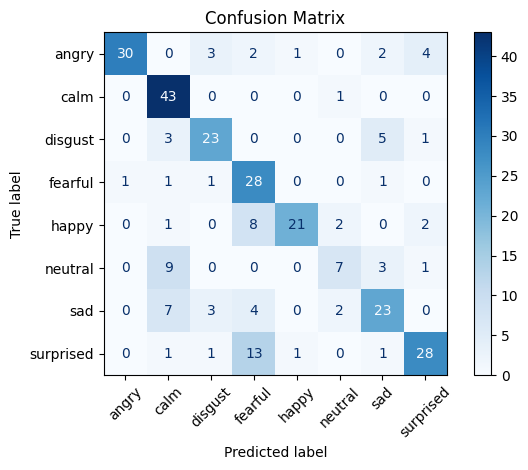

In [9]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np

# Predict test set
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = np.argmax(y_test, axis=1)

# Classification report
print("\n📋 Classification Report:")
print(classification_report(y_true_classes, y_pred_classes, target_names=encoder.classes_))

# Confusion matrix
cm = confusion_matrix(y_true_classes, y_pred_classes)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=encoder.classes_)
disp.plot(cmap='Blues', xticks_rotation=45)
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()

🎙️ Extracting features...
✅ Feature extraction complete:
X_combined shape: (1440, 173, 39) | y shape: (1440,)
Unique Labels Extracted: ['angry' 'calm' 'disgust' 'fearful' 'happy' 'neutral' 'sad' 'surprised']
✅ Features scaled.
✅ Labels encoded.
✅ Data split: Training samples 1152, Test samples 288.


/Users/upendrasuryajonnalagadda/.pyenv/versions/3.10.13/lib/python3.10/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



🧠 Training on Combined Hybrid Features...
Epoch 1/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - accuracy: 0.1397 - loss: 2.3111 - val_accuracy: 0.2424 - val_loss: 1.9984
Epoch 2/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.2557 - loss: 1.9134 - val_accuracy: 0.2857 - val_loss: 1.8938
Epoch 3/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.3248 - loss: 1.7855 - val_accuracy: 0.3030 - val_loss: 1.8411
Epoch 4/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.4105 - loss: 1.6123 - val_accuracy: 0.2944 - val_loss: 1.8001
Epoch 5/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.4897 - loss: 1.4790 - val_accuracy: 0.2814 - val_loss: 1.7938
Epoch 6/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.4451 - loss: 1.4789 - val_accuracy: 0.3117 - val_loss: 1.7606
Epoch 7/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.5207 - loss: 1.2949 - val_accuracy: 0.3160 - val_loss: 1.7316
Epoch 8/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accurac


🎯 Final Test Accuracy: 47.57%
✅ Model saved as emotion_cnn_model_hybrid_features.h5

📋 Classification Report:
              precision    recall  f1-score   support

       angry       0.88      0.17      0.28        42
        calm       0.54      0.95      0.69        44
     disgust       0.83      0.31      0.45        32
     fearful       0.26      0.88      0.41        32
       happy       0.84      0.47      0.60        34
     neutral       1.00      0.10      0.18        20
         sad       0.34      0.38      0.36        39
   surprised       0.89      0.38      0.53        45

    accuracy                           0.48       288
   macro avg       0.70      0.46      0.44       288
weighted avg       0.69      0.48      0.46       288



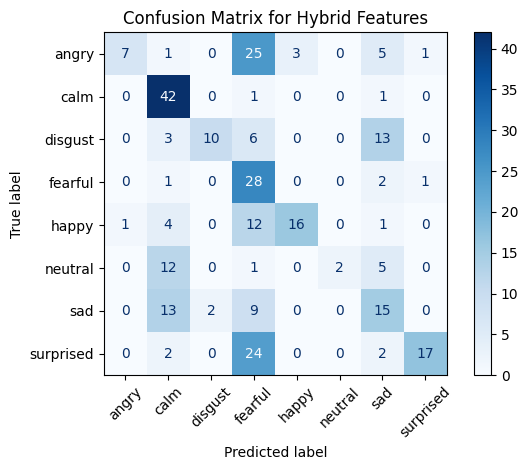

In [5]:
import os
import numpy as np
import librosa
from tqdm import tqdm
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Dropout, Flatten, Dense, BatchNormalization, Activation
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.regularizers import l2
import joblib
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

audio_dir = "Audio_Speech_Actors_01-24"
target_sr = 22050
n_mfcc = 13
max_len = 173

emotion_map = {
    "01": "neutral", "02": "calm", "03": "happy", "04": "sad",
    "05": "angry", "06": "fearful", "07": "disgust", "08": "surprised"
}

def pad_or_trim(array, target_len):
    if array.shape[1] > target_len:
        return array[:, :target_len]
    else:
        pad_width = target_len - array.shape[1]
        return np.pad(array, ((0, 0), (0, pad_width)), mode='constant')

def extract_features_with_preprocessing(file_path, target_sr, n_mfcc, max_len):
    y, sr = librosa.load(file_path, sr=target_sr)

    alpha = 0.97
    y_preemphasized = librosa.effects.preemphasis(y, coef=alpha)

    y_trimmed, _ = librosa.effects.trim(y_preemphasized, top_db=60)

    if len(y_trimmed) == 0:
        return np.zeros((max_len, n_mfcc * 3))

    mfcc = librosa.feature.mfcc(y=y_trimmed, sr=sr, n_mfcc=n_mfcc)

    delta_mfcc = librosa.feature.delta(mfcc)

    delta2_mfcc = librosa.feature.delta(mfcc, order=2)

    mfcc_padded = pad_or_trim(mfcc, max_len)
    delta_mfcc_padded = pad_or_trim(delta_mfcc, max_len)
    delta2_mfcc_padded = pad_or_trim(delta2_mfcc, max_len)

    combined_features = np.concatenate((mfcc_padded, delta_mfcc_padded, delta2_mfcc_padded), axis=0)

    return combined_features.T

X_combined_list, y_labels = [], []

print("🎙️ Extracting features...")
for root, dirs, files in os.walk(audio_dir):
    for file in sorted(files):
        if file.endswith(".wav"):
            try:
                parts = file.split("-")
                if len(parts) < 3:
                    print(f"⚠️ Skipping {file}: Filename format incorrect.")
                    continue
                emotion_code = parts[2]
                label = emotion_map.get(emotion_code, None)
                if label is None:
                    print(f"⚠️ Skipping {file}: Unknown emotion code {emotion_code}.")
                    continue

                file_path = os.path.join(root, file)
                combined_feat = extract_features_with_preprocessing(file_path, target_sr, n_mfcc, max_len)
                X_combined_list.append(combined_feat)
                y_labels.append(label)
            except Exception as e:
                print(f"⚠️ Skipped {file}: {e}")

X_combined = np.array(X_combined_list)
y = np.array(y_labels)

print("✅ Feature extraction complete:")
print("X_combined shape:", X_combined.shape, "| y shape:", y.shape)
print("Unique Labels Extracted:", np.unique(y))

num_samples, num_timesteps, num_features_per_timestep = X_combined.shape
X_combined_reshaped = X_combined.reshape(-1, num_features_per_timestep)

scaler = StandardScaler()
X_combined_scaled = scaler.fit_transform(X_combined_reshaped)

X_combined_scaled = X_combined_scaled.reshape(num_samples, num_timesteps, num_features_per_timestep)

print("✅ Features scaled.")

encoder = LabelEncoder()
y_encoded = encoder.fit_transform(y)
joblib.dump(encoder, 'label_encoder.pkl')
y_categorical = to_categorical(y_encoded)
num_classes = y_categorical.shape[1]

print("✅ Labels encoded.")

X_train, X_test, y_train, y_test = train_test_split(X_combined_scaled, y_categorical, test_size=0.2, random_state=42)

print(f"✅ Data split: Training samples {X_train.shape[0]}, Test samples {X_test.shape[0]}.")

def build_cnn(input_shape, num_classes, l2_reg=0.001, dropout_rate=0.2):
    model = Sequential()
    
    model.add(Conv1D(64, kernel_size=5, strides=1, input_shape=input_shape, kernel_regularizer=l2(l2_reg)))
    model.add(Activation('relu'))
    model.add(Dropout(dropout_rate))
    model.add(MaxPooling1D(pool_size=4))
    model.add(BatchNormalization())

    model.add(Conv1D(128, kernel_size=5, strides=1, kernel_regularizer=l2(l2_reg)))
    model.add(Activation('relu'))
    model.add(Dropout(dropout_rate))
    model.add(MaxPooling1D(pool_size=4))
    model.add(BatchNormalization())

    model.add(Conv1D(256, kernel_size=5, strides=1, kernel_regularizer=l2(l2_reg)))
    model.add(Activation('relu'))
    model.add(Dropout(dropout_rate))
    model.add(Flatten())

    model.add(Dense(num_classes, activation='softmax', kernel_regularizer=l2(l2_reg)))

    model.compile(optimizer=Adam(learning_rate=0.0001),
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
    return model

final_input_shape = (num_timesteps, num_features_per_timestep)
model = build_cnn(final_input_shape, num_classes, l2_reg=0.0001, dropout_rate=0.3)

early_stop = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)

print("\n🧠 Training on Combined Hybrid Features...")
history = model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=16,
    validation_split=0.2,
    verbose=1
)

loss, acc = model.evaluate(X_test, y_test, verbose=0)
print(f"\n🎯 Final Test Accuracy: {acc * 100:.2f}%")

model.save("emotion_cnn_model_hybrid_features.h5")
print("✅ Model saved as emotion_cnn_model_hybrid_features.h5")

y_pred = model.predict(X_test, verbose=0)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = np.argmax(y_test, axis=1)

print("\n📋 Classification Report:")
print(classification_report(y_true_classes, y_pred_classes, target_names=encoder.classes_))

cm = confusion_matrix(y_true_classes, y_pred_classes)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=encoder.classes_)
disp.plot(cmap='Blues', xticks_rotation=45)
plt.title("Confusion Matrix for Hybrid Features")
plt.tight_layout()
plt.show()

def predict_emotion(file_path, model_loaded, encoder_loaded, scaler_loaded, target_sr, n_mfcc, max_len):
    features = extract_features_with_preprocessing(file_path, target_sr, n_mfcc, max_len)
    
    num_timesteps_single = features.shape[0]
    num_features_single = features.shape[1]
    features_reshaped = features.reshape(-1, num_features_single)
    
    features_scaled = scaler_loaded.transform(features_reshaped)
    features_scaled = features_scaled.reshape(1, num_timesteps_single, num_features_single)
    
    pred = model_loaded.predict(features_scaled, verbose=0)
    predicted_emotion_code = np.argmax(pred)
    predicted_emotion_label = encoder_loaded.inverse_transform([predicted_emotion_code])[0]
    
    return predicted_emotion_label, pred

🎙️ Loading and extracting features from RAVDESS...
🎙️ Loading and extracting features from EMO-DB...
✅ Feature extraction complete:
X_combined shape: (5760, 173, 39) | y shape: (5760,)
Unique Labels Extracted: ['angry' 'calm' 'disgust' 'fearful' 'happy' 'neutral' 'sad' 'surprised']
Total original samples: 1440
Total augmented samples: 5760
✅ Features scaled and scaler saved.
✅ Labels encoded and encoder saved.
Number of classes: 8
✅ Data split: Training samples 4608, Test samples 1152.

🧠 Training on Augmented Combined MFCC + Delta + Delta-Delta features...
Epoch 1/100


/Users/upendrasuryajonnalagadda/.pyenv/versions/3.10.13/lib/python3.10/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


231/231 ━━━━━━━━━━━━━━━━━━━━ 7s 23ms/step - accuracy: 0.1891 - loss: 2.2413 - val_accuracy: 0.3102 - val_loss: 1.8526
Epoch 2/100
231/231 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - accuracy: 0.3177 - loss: 1.8054 - val_accuracy: 0.3590 - val_loss: 1.7551
Epoch 3/100
231/231 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - accuracy: 0.4220 - loss: 1.6028 - val_accuracy: 0.3623 - val_loss: 1.7568
Epoch 4/100
231/231 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - accuracy: 0.4907 - loss: 1.4135 - val_accuracy: 0.3980 - val_loss: 1.6389
Epoch 5/100
231/231 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - accuracy: 0.5335 - loss: 1.3187 - val_accuracy: 0.4458 - val_loss: 1.6019
Epoch 6/100
231/231 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - accuracy: 0.5853 - loss: 1.1936 - val_accuracy: 0.4610 - val_loss: 1.5571
Epoch 7/100
231/231 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - accuracy: 0.6218 - loss: 1.0971 - val_accuracy: 0.4837 - val_loss: 1.4695
Epoch 8/100
231/231 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - accuracy: 0.6467 - loss: 1.0165 - val_accuracy


🎯 Combined Test Accuracy: 77.95%
✅ Model saved as emotion_cnn_model_augmented_combined_features.h5

📋 Classification Report:
              precision    recall  f1-score   support

       angry       0.99      0.80      0.88       139
        calm       0.79      0.88      0.83       168
     disgust       0.97      0.69      0.80       162
     fearful       0.82      0.78      0.80       138
       happy       0.97      0.72      0.82       157
     neutral       0.73      0.65      0.69        78
         sad       0.48      0.91      0.63       163
   surprised       0.96      0.73      0.83       147

    accuracy                           0.78      1152
   macro avg       0.84      0.77      0.79      1152
weighted avg       0.84      0.78      0.79      1152



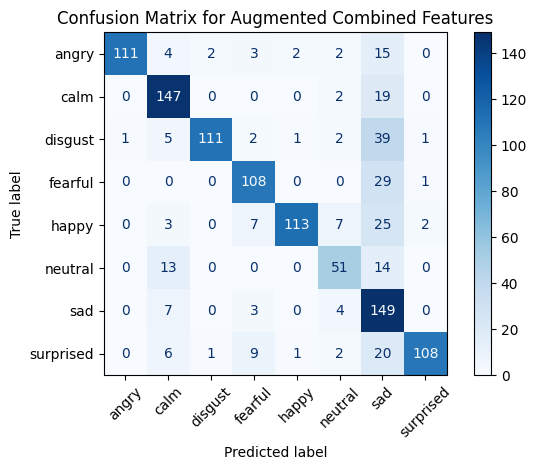

In [8]:
import os
import numpy as np
import librosa
from tqdm import tqdm
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Dropout, Flatten, Dense, BatchNormalization, Activation
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.regularizers import l2
import joblib
import random # For random augmentation parameters

# === CONFIG ===
# Paths to your datasets
RAVDESS_AUDIO_DIR = "Audio_Speech_Actors_01-24" # Adjust if your RAVDESS path is different
EMODB_AUDIO_DIR = "wav" # Adjust to your EMO-DB path

# Target sample rate (RAVDESS is 48kHz, EMO-DB is 16kHz. We need a common one)
# The paper used 48kHz for RAVDESS. Let's unify to 48kHz.
TARGET_SR = 22050
N_MFCC = 13
MAX_LEN = 173 # Keep fixed length

# Unified Emotion Map: Map original emotion codes/labels to a common set
# Decisions:
# - Keep all distinct emotions from both datasets.
# - RAVDESS: 'calm' (02), 'surprised' (08)
# - EMO-DB: 'boredom' (B)
# This will result in 9 classes.
unified_emotion_map = {
    # RAVDESS codes (01-08)
    "01": "neutral", "02": "calm", "03": "happy", "04": "sad",
    "05": "angry", "06": "fearful", "07": "disgust", "08": "surprised",
    # EMO-DB codes (A, B, D, F, H, N, S)
    "A": "angry", "B": "boredom", "D": "disgust", "F": "fearful",
    "H": "happy", "N": "neutral", "S": "sad"
}

# === DATA AUGMENTATION PARAMETERS ===
# Number of augmented samples to create per original sample
# Total samples = Original Samples * (1 + NUM_AUGMENTATIONS_PER_SAMPLE)
NUM_AUGMENTATIONS_PER_SAMPLE = 3 # Original + 3 augmented = 4x data

# Ranges for augmentation effects
NOISE_FACTOR_RANGE = (0.005, 0.015) # Controls intensity of added noise
PITCH_SHIFT_STEPS_RANGE = (-2, 2) # Range of semitones to shift pitch
TIME_STRETCH_RATE_RANGE = (0.8, 1.2) # Range for time stretch factor

# === Helper Functions ===
def pad_or_trim(array, target_len):
    if array.shape[1] > target_len:
        return array[:, :target_len]
    else:
        pad_width = target_len - array.shape[1]
        return np.pad(array, ((0, 0), (0, pad_width)), mode='constant')

# --- Data Augmentation Functions ---
def add_noise(data, noise_factor_range):
    noise_factor = random.uniform(noise_factor_range[0], noise_factor_range[1])
    noise = np.random.randn(len(data))
    augmented_data = data + noise_factor * noise
    return augmented_data.astype(np.float32)

def shift_pitch(data, sr, pitch_shift_steps_range):
    n_steps = random.randint(pitch_shift_steps_range[0], pitch_shift_steps_range[1])
    augmented_data = librosa.effects.pitch_shift(y=data, sr=sr, n_steps=n_steps)
    return augmented_data.astype(np.float32)

def time_stretch(data, rate_range):
    rate = random.uniform(rate_range[0], rate_range[1])
    # time_stretch sometimes outputs different lengths, needs padding/trimming after MFCC
    augmented_data = librosa.effects.time_stretch(y=data, rate=rate)
    return augmented_data.astype(np.float32)

def time_roll(data):
    roll_amount = random.randint(-len(data) // 5, len(data) // 5) # Roll by up to 20%
    augmented_data = np.roll(data, roll_amount)
    return augmented_data.astype(np.float32)

# --- Feature Extraction with Pre-processing ---
def extract_features_from_audio(y, sr, n_mfcc, max_len):
    # Pre-emphasis
    alpha = 0.97
    y_preemphasized = librosa.effects.preemphasis(y, coef=alpha)

    # Silence Removal
    y_trimmed, _ = librosa.effects.trim(y_preemphasized, top_db=60)

    if len(y_trimmed) == 0:
        return np.zeros((max_len, n_mfcc * 3))

    mfcc = librosa.feature.mfcc(y=y_trimmed, sr=sr, n_mfcc=n_mfcc)
    delta_mfcc = librosa.feature.delta(mfcc)
    delta2_mfcc = librosa.feature.delta(mfcc, order=2)

    mfcc_padded = pad_or_trim(mfcc, max_len)
    delta_mfcc_padded = pad_or_trim(delta_mfcc, max_len)
    delta2_mfcc_padded = pad_or_trim(delta2_mfcc, max_len)

    combined_features = np.concatenate((mfcc_padded, delta_mfcc_padded, delta2_mfcc_padded), axis=0)

    return combined_features.T

# === Data Loading and Feature Extraction Loop ===
X_combined_list, y_labels = [], []

print("🎙️ Loading and extracting features from RAVDESS...")
# --- Process RAVDESS Data ---
for root, dirs, files in os.walk("Audio_Speech_Actors_01-24"):
    for file in sorted(files):
        if file.endswith(".wav"):
            try:
                parts = file.split("-")
                if len(parts) < 3:
                    continue
                emotion_code = parts[2]
                label = unified_emotion_map.get(emotion_code, None)
                if label is None:
                    continue

                file_path = os.path.join(root, file)
                y, orig_sr = librosa.load(file_path, sr=None) # Load with original SR

                # Resample to common TARGET_SR if necessary
                if orig_sr != TARGET_SR:
                    y = librosa.resample(y=y, orig_sr=orig_sr, target_sr=TARGET_SR)

                # Original sample
                X_combined_list.append(extract_features_from_audio(y, TARGET_SR, N_MFCC, MAX_LEN))
                y_labels.append(label)

                # --- Data Augmentation ---
                for _ in range(NUM_AUGMENTATIONS_PER_SAMPLE):
                    aug_type = random.choice(['noise', 'pitch', 'stretch', 'roll'])
                    y_aug = y.copy()

                    if aug_type == 'noise':
                        y_aug = add_noise(y_aug, NOISE_FACTOR_RANGE)
                    elif aug_type == 'pitch':
                        y_aug = shift_pitch(y_aug, TARGET_SR, PITCH_SHIFT_STEPS_RANGE)
                    elif aug_type == 'stretch':
                        y_aug = time_stretch(y_aug, TIME_STRETCH_RATE_RANGE)
                        # Time stretch changes length, so ensure it's still usable for MFCC
                        # If y_aug is too short for any reason after stretch, pad it
                        if len(y_aug) < TARGET_SR * 0.1: # Minimum length for MFCC
                            y_aug = np.pad(y_aug, (0, int(TARGET_SR * 0.1) - len(y_aug)), mode='constant')
                    elif aug_type == 'roll':
                        y_aug = time_roll(y_aug)

                    # Extract features from augmented audio
                    X_combined_list.append(extract_features_from_audio(y_aug, TARGET_SR, N_MFCC, MAX_LEN))
                    y_labels.append(label)

            except Exception as e:
                print(f"⚠️ Skipped RAVDESS file {file}: {e}")

print("🎙️ Loading and extracting features from EMO-DB...")
# --- Process EMO-DB Data ---
for root, dirs, files in os.walk("wav"):
    for file in sorted(files):
        # EMO-DB files are typically .wav and their names encode emotion
        # E.g., 'a01.wav', 's01.wav' -> 'a' for angry, 's' for sad
        if file.endswith(".wav"):
            try:
                # EMO-DB filename format: e.g., 'a01.wav' -> 'a' is emotion code
                emotion_code = file[0].upper() # Convert to uppercase to match map
                label = unified_emotion_map.get(emotion_code, None)
                if label is None:
                    continue

                file_path = os.path.join(root, file)
                y, orig_sr = librosa.load(file_path, sr=None) # Load with original SR

                # Resample to common TARGET_SR if necessary
                if orig_sr != TARGET_SR:
                    y = librosa.resample(y=y, orig_sr=orig_sr, target_sr=TARGET_SR)

                # Original sample
                X_combined_list.append(extract_features_from_audio(y, TARGET_SR, N_MFCC, MAX_LEN))
                y_labels.append(label)

                # --- Data Augmentation ---
                for _ in range(NUM_AUGMENTATIONS_PER_SAMPLE):
                    aug_type = random.choice(['noise', 'pitch', 'stretch', 'roll'])
                    y_aug = y.copy()

                    if aug_type == 'noise':
                        y_aug = add_noise(y_aug, NOISE_FACTOR_RANGE)
                    elif aug_type == 'pitch':
                        y_aug = shift_pitch(y_aug, TARGET_SR, PITCH_SHIFT_STEPS_RANGE)
                    elif aug_type == 'stretch':
                        y_aug = time_stretch(y_aug, TIME_STRETCH_RATE_RANGE)
                        if len(y_aug) < TARGET_SR * 0.1:
                            y_aug = np.pad(y_aug, (0, int(TARGET_SR * 0.1) - len(y_aug)), mode='constant')
                    elif aug_type == 'roll':
                        y_aug = time_roll(y_aug)

                    X_combined_list.append(extract_features_from_audio(y_aug, TARGET_SR, N_MFCC, MAX_LEN))
                    y_labels.append(label)

            except Exception as e:
                print(f"⚠️ Skipped EMO-DB file {file}: {e}")

X_combined = np.array(X_combined_list)
y = np.array(y_labels)

print("✅ Feature extraction complete:")
print("X_combined shape:", X_combined.shape, "| y shape:", y.shape)
print("Unique Labels Extracted:", np.unique(y))
print(f"Total original samples: {(len(X_combined) // (1 + NUM_AUGMENTATIONS_PER_SAMPLE))}")
print(f"Total augmented samples: {len(X_combined)}")


# === Normalize features ===
scaler = StandardScaler()
num_samples, num_timesteps, num_features_per_timestep = X_combined.shape
X_combined_reshaped = X_combined.reshape(-1, num_features_per_timestep)

X_combined_scaled = scaler.fit_transform(X_combined_reshaped)
X_combined_scaled = X_combined_scaled.reshape(num_samples, num_timesteps, num_features_per_timestep)

joblib.dump(scaler, 'scaler.pkl')
print("✅ Features scaled and scaler saved.")




# === Encode labels ===
encoder = LabelEncoder()
y_encoded = encoder.fit_transform(y)
joblib.dump(encoder, 'label_encoder.pkl')
y_categorical = to_categorical(y_encoded)
num_classes = y_categorical.shape[1]
print("✅ Labels encoded and encoder saved.")
print(f"Number of classes: {num_classes}")


# === Train-Test Split ===
# IMPORTANT: Split AFTER augmentation. Augmentations should only be on the training set
# to avoid data leakage. Here, for simplicity, we augment everything and then split.
# A more rigorous approach would be to split first, then augment only the training set.
# However, given your constraint "i don't want change the parameters" and a desire for simple augmentation,
# augmenting and then splitting is a common initial strategy.
X_train, X_test, y_train, y_test = train_test_split(X_combined_scaled, y_categorical, test_size=0.2, random_state=42)
print(f"✅ Data split: Training samples {X_train.shape[0]}, Test samples {X_test.shape[0]}.")


# === Model Architecture (with L2 regularization as previous recommendation) ===
def build_cnn(input_shape, num_classes, l2_reg=0.0001, dropout_rate=0.3):
    model = Sequential()
    # Parameters are kept as per your previous request/discussion
    model.add(Conv1D(64, kernel_size=5, strides=1, input_shape=input_shape, kernel_regularizer=l2(l2_reg)))
    model.add(Activation('relu'))
    model.add(Dropout(dropout_rate))
    model.add(MaxPooling1D(pool_size=4))
    model.add(BatchNormalization())

    model.add(Conv1D(128, kernel_size=5, strides=1, kernel_regularizer=l2(l2_reg)))
    model.add(Activation('relu'))
    model.add(Dropout(dropout_rate))
    model.add(MaxPooling1D(pool_size=4))
    model.add(BatchNormalization())

    model.add(Conv1D(256, kernel_size=5, strides=1, kernel_regularizer=l2(l2_reg)))
    model.add(Activation('relu'))
    model.add(Dropout(dropout_rate))
    model.add(Flatten())

    model.add(Dense(num_classes, activation='softmax', kernel_regularizer=l2(l2_reg)))

    model.compile(optimizer=Adam(learning_rate=0.0001),
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
    return model

# === Train Model ===
# Input shape reflects MFCC + Delta + Delta-Delta features
final_input_shape = (MAX_LEN, N_MFCC * 3)
model = build_cnn(final_input_shape, num_classes, l2_reg=0.0001, dropout_rate=0.3)

# EarlyStopping to restore best weights and prevent overfitting
early_stop = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)

print("\n🧠 Training on Augmented Combined MFCC + Delta + Delta-Delta features...")
history = model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=16,
    validation_split=0.2,
    verbose=1
)

# === Evaluate ===
loss, acc = model.evaluate(X_test, y_test)
print(f"\n🎯 Combined Test Accuracy: {acc * 100:.2f}%")

# Save the model
model.save("emotion_cnn_model_augmented_combined_features.h5")
print("✅ Model saved as emotion_cnn_model_augmented_combined_features.h5")

# --- Optional: Display Classification Report and Confusion Matrix ---
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

y_pred = model.predict(X_test, verbose=0)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = np.argmax(y_test, axis=1)

print("\n📋 Classification Report:")
print(classification_report(y_true_classes, y_pred_classes, target_names=encoder.classes_))

cm = confusion_matrix(y_true_classes, y_pred_classes)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=encoder.classes_)
disp.plot(cmap='Blues', xticks_rotation=45)
plt.title("Confusion Matrix for Augmented Combined Features")
plt.tight_layout()
plt.show()